# Risk Management Project 2 – Bonds Valuation and Hedging

## Introduction

In this project, we focus on the valuation and risk analysis of bonds using the term structure of interest rates. The objective is to construct the yield curve, compute bond prices, and analyze sensitivities such as duration and convexity.

## 1. Bonds and Interest Rates

A bond is a financial instrument through which an investor lends money to a borrower, usually a government or a corporation. In return, the issuer agrees to pay periodic interest (called coupons) and to repay the principal at maturity. Bonds are typically issued on primary markets, either through auctions or with the help of financial intermediaries.

There is an inverse relationship between bond prices and interest rates. When interest rates increase, new bonds offer higher returns, making existing bonds less attractive, so their price decreases. On the other hand, when interest rates decrease, existing bonds become more valuable, and their price increases.



## 2. Data Collection and Spot Yield Curve

We selected the AAA-rated euro area spot yield curve from the European Central Bank (ECB) for 19 March 2026.

We selected this date and then extracted 10 consecutive semi-annual spot yield from the spot yield curve for the following maturities: 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, and 5.0 years, which together represent a 5-year horizon.

The spot yields, also called zero-coupon rates or spot rates, correspond to a single maturity. 

In [38]:
import pandas as pd

date_selected = "2026-03-19"

series = {
    "0.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M",
    "1.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y",
    "1.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y6M",
    "2.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y",
    "2.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y6M",
    "3.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y",
    "3.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y6M",
    "4.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y",
    "4.5Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y6M",
    "5.0Y": "YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y",
}

rows = []

for maturity, code in series.items():
    url = f"https://data-api.ecb.europa.eu/service/data/YC/{code.split('YC.')[1]}?format=csvdata"
    df_tmp = pd.read_csv(url)
    df_tmp.columns = [c.upper() for c in df_tmp.columns]

    value_row = df_tmp[df_tmp["TIME_PERIOD"] == date_selected]

    rows.append({
        "maturity": float(maturity.replace("Y", "")),
        "spot_rate": float(value_row["OBS_VALUE"].iloc[0])
    })

spot_df = pd.DataFrame(rows).sort_values("maturity")
spot_df = pd.read_csv("/Users/evelyn/Desktop/M2/risk/ecb_spot_rates.csv")
spot_df

,maturity,spot_rate
0,0.5,2.158183
1,1.0,2.337735
2,1.5,2.424372
3,2.0,2.468185
4,2.5,2.494950
5,3.0,2.517302
6,3.5,2.540909
7,4.0,2.567863
8,4.5,2.598506
9,5.0,2.632398


## 3. Spot Rate: Definition, Characteristics, Derivation and Interpretation

A spot rate is the interest rate applicable today for a single cash flow at a given maturity. Therefore, it is the yield to maturity on a zero-coupon bond. This spot rate is used to discount one future cash flow back to today.

The main characteristics of the spot rate are:
- it is used to discount a single cash flow to today
- it is different for each maturity
- the spot yield curve shows the relation between spot rates and maturities

A spot rate is derived from the market through boostrapping, which is a technique wherein spot rates are obtained from the prices of coupon-bearing instruments such as bonds and swaps, or directly from zero-coupon bonds. When zero-coupon bonds are available, the spot rate is obtained from the bond price using this equation

$$
y = m\left[\left(\frac{M}{P}\right)^{\frac{1}{m \times n}} - 1\right]
$$

where:

- \(y\) is the spot rate,
- \(P\) is the present value of the zero-coupon bond,
- \(M\) is the par value,
- \(n\) is the number of years,
- \(m\) is the number of periods per year.

The spot rate in this project is directly collected from the ECB AAA yield curve. Thus, the market already provides the zero-coupon term structure so no additional manual bootstrapping is required.

In [39]:
import pandas as pd

print("The following figure plots the 10 selected semi-annual spot yields from 0.5 to 5.0 years.")
df = pd.read_csv("/Users/evelyn/Desktop/M2/risk/ecb_spot_rates.csv")
df

The following figure plots the 10 selected semi-annual spot yields from 0.5 to 5.0 years.


,maturity,spot_rate
0,0.5,2.158183
1,1.0,2.337735
2,1.5,2.424372
3,2.0,2.468185
4,2.5,2.494950
5,3.0,2.517302
6,3.5,2.540909
7,4.0,2.567863
8,4.5,2.598506
9,5.0,2.632398


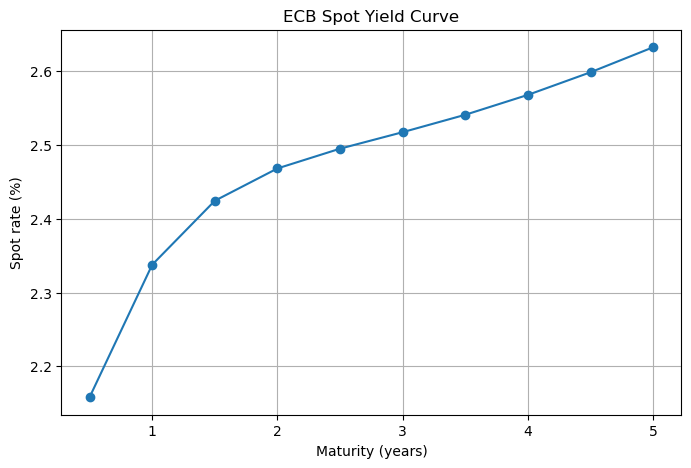

In [40]:
import matplotlib.pyplot as plt
maturities = df["maturity"].tolist()
spot_rates_pct = df["spot_rate"].tolist()

plt.figure(figsize=(8,5))
plt.plot(maturities, spot_rates_pct, marker="o")
plt.xlabel("Maturity (years)")
plt.ylabel("Spot rate (%)")
plt.title("ECB Spot Yield Curve")
plt.grid(True)
plt.show()

The plotted spot yield curve is upward sloping over the 0.5 year to 5 year horizon. This means that yield are higher in the long term.

From a macroeconomic perspective, an upward-sloping yield curve is interpreted as a normal yield curve as it is associated with expectations of economic expansion, positive future growth, and possibly higher future interest rates. 

In this case, the curve rises gradually from the short term to long term maturities, suggesting that investors require higher yields to lend money for longer periods. This behaviour may reflect expectations of firmer future economic activity, inflation, or tighter monetary conditions over time.

## 4. Linear Interpolation of a Semi-Annual Spot Yield

To estimate one semi-annual spot yield by linear interpolation, we use two non-consecutive observed spot yields and interpolate the missing maturity between them.

We choose:
- \(n_1 = 1.0\) year, with observed spot yield \(s_{1.0} = 2.337735\%\)
- \(n_3 = 2.0\) years, with observed spot yield \(s_{2.0} = 2.468185\%\)

We then estimate the intermediate semi-annual spot yield at:
- \(n_2 = 1.5\) years


In [41]:
# Q4 - Interpolate the 1.5Y spot rate and compare it with the ECB value

# Read the spot rates saved in the local data folder
import pandas as pd

df = pd.read_csv("/Users/evelyn/Desktop/M2/risk/ecb_spot_rates.csv")

# Extract the two surrounding spot rates: 1Y and 2Y
r_1y = df.loc[df["maturity"] == 1.0, "spot_rate"].values[0]
r_2y = df.loc[df["maturity"] == 2.0, "spot_rate"].values[0]

# Linear interpolation for the 1.5Y maturity
t1 = 1.0
t2 = 2.0
t_mid = 1.5

r_interp = r_1y + (r_2y - r_1y) * (t_mid - t1) / (t2 - t1)

# Actual ECB value for 1.5Y
r_actual = df.loc[df["maturity"] == 1.5, "spot_rate"].values[0]

# Pricing interpolation error
interp_error = r_interp - r_actual
abs_error = abs(interp_error)

print("Q4 Results")
print("----------")
print("1Y spot rate (%):", r_1y)
print("2Y spot rate (%):", r_2y)
print("Interpolated 1.5Y spot rate (%):", r_interp)
print("Actual ECB 1.5Y spot rate (%):", r_actual)
print("Interpolation error:", interp_error)
print("Absolute error:", abs_error)

Q4 Results
----------
1Y spot rate (%): 2.3377346321
2Y spot rate (%): 2.4681846638
Interpolated 1.5Y spot rate (%): 2.40295964795
Actual ECB 1.5Y spot rate (%): 2.4243723534
Interpolation error: -0.021412705449999958
Absolute error: 0.021412705449999958


In [42]:
# Q4 - Summary table for interpolation comparison

comparison_q4 = pd.DataFrame({
    "Maturity": [1.0, 1.5, 2.0],
    "Spot Rate (%)": [r_1y, r_actual, r_2y]
})

comparison_q4

,Maturity,Spot Rate (%)
0,1.0,2.337735
1,1.5,2.424372
2,2.0,2.468185


### Interpretation
Using linear interpolation, the estimated spot yield is:

$$
s_{n_2}^{\text{est}} = s_{n_1} + \frac{n_2 - n_1}{n_3 - n_1}\left(s_{n_3} - s_{n_1}\right)
$$

Substituting the values:

$$
s_{1.5}^{\text{est}} = 2.337735 + \frac{1.5 - 1.0}{2.0 - 1.0}\left(2.468185 - 2.337735\right)
$$

$$
s_{1.5}^{\text{est}} = 2.337735 + 0.5 \times 0.130450
$$

$$
s_{1.5}^{\text{est}} = 2.402960\%
$$

The observed spot yield at 1.5 years from the ECB curve is:

$$
s_{1.5}^{\text{obs}} = 2.424372\%
$$

Therefore, the interpolation error is:

$$
\text{Error} = s_{1.5}^{\text{obs}} - s_{1.5}^{\text{est}} = 2.424372 - 2.402960 = 0.021412\%
$$

We find that the interpolated 1.5 year spot rate is very close to the observed value. The small difference of about 0.02% confirms that linear interpolation can provide a reasonable approximation for an intermediate maturity even though the actual spot yield curve is not perfectly linear between observed points.
This could explain why the interpolated value slightly underestimates the actual rate.

## 5. STRIPS Prices Implied by the 10 Spot Rates

To calculate the price of the 10 STRIPS, we reverse the spot-rate equation for zero-coupon bonds:

$$
y = m\left[\left(\frac{M}{P}\right)^{\frac{1}{m \cdot n}} - 1\right]
$$

Solving for the STRIPS price \(P\), we obtain:

$$
P = \frac{M}{\left(1 + \frac{y}{m}\right)^{m \cdot n}}
$$

where:
- \(P\) is the price of the STRIP,
- \(M = 100\) is the par value,
- \(y\) is the spot yield in decimal form,
- \(m = 2\) because compounding is semi-annual,
- \(n\) is the maturity in years.

Using this formula, we calculate the price of each STRIP corresponding to the 10 selected semi-annual spot yields.

In [43]:
# Q5 - Calculate the prices of the 10 STRIPS from the 10 ECB spot rates

import pandas as pd

# Read the ECB spot rates saved in the local data folder
df = pd.read_csv("/Users/evelyn/Desktop/M2/risk/ecb_spot_rates.csv")

# Parameters
PAR_VALUE = 100
M = PAR_VALUE
m = 2   # semi-annual compounding

# Manual computation of STRIPS prices
strip_rows = []

for _, row in df.iterrows():
    maturity_years = row["maturity"]
    spot_rate_pct = row["spot_rate"]
    s_i = spot_rate_pct / 100.0
    i = int(maturity_years * m)   # number of semi-annual periods

    # STRIP pricing equation:
    # P = M / (1 + s_i / m)^i
    strip_price = M / ((1 + s_i / m) ** i)

    if strip_price < M:
        status = "Below par"
    elif strip_price > M:
        status = "Above par"
    else:
        status = "At par"

    strip_rows.append({
        "Maturity (years)": maturity_years,
        "Periods i": i,
        "Spot rate (%)": spot_rate_pct,
        "STRIP price (€)": strip_price,
        "Position vs par": status
    })

df_strips = pd.DataFrame(strip_rows)

print("Q5 Results")
print("----------")
print(df_strips)

df_strips

# Q5 - Save STRIPS prices

df_strips.to_csv("/Users/evelyn/Desktop/M2/risk/strip_prices.csv", index=False)

Q5 Results
----------
   Maturity (years)  Periods i  Spot rate (%)  STRIP price (€) Position vs par
0               0.5          1       2.158183        98.932429       Below par
1               1.0          2       2.337735        97.702623       Below par
2               1.5          3       2.424372        96.449856       Below par
3               2.0          4       2.468185        95.212250       Below par
4               2.5          5       2.494950        93.989425       Below par
5               3.0          6       2.517302        92.769919       Below par
6               3.5          7       2.540909        91.542061       Below par
7               4.0          8       2.567863        90.297472       Below par
8               4.5          9       2.598506        89.031525       Below par
9               5.0         10       2.632398        87.742725       Below par


### Interpretation

All STRIPS are priced below par value, which is expected because a STRIP is a zero-coupon bond. This means that it does not pay intermediate coupons and only pays its par value at maturity. Thus, when the spot yield is positive, the present value of the future payment must be lower than the par value. 

So because all selected spot yeilds are positive, each STRIP trades at a discount relative to its  €100 par value.

Prices do decrease as maturity rises, showing a stronger impact of discounting over longer periods. This is consistent with the upward-sloping spot yield curve observed earlier. 

## 6. Forward Rate

A forward rate is the interest rate derived from the current spot rate. It is agreed today for an investment or loan that will start at a future date and end at a later future date.

The main characteristics are:
- it is an interest rate for a future period;
- it is implied by current spot rates observed in the market;
- it is not directly observed but derived from the term structure of interest rates;
- it can be used to value future cash flows and to interpret market expectations about future interest rates.

Forward rates are derived from spot rates by using the no-arbitrage condition between discount factors at different maturities. With semi-annual compounding, the relation between two consecutive maturities can be written as:

$$
\left(1+\frac{s_t}{m}\right)^{m t}
=
\left(1+\frac{s_{t-1}}{m}\right)^{m (t-0.5)}
\left(1+\frac{f_t}{m}\right)
$$

where:
- \(s_t\) is the spot rate for maturity \(t\),
- \(s_{t-1}\) is the spot rate for the previous semi-annual maturity,
- \(f_t\) is the forward rate for the period from \(t-0.5\) to \(t\),
- \(m = 2\) because compounding is semi-annual.

Rearranging the formula gives the forward rate:

$$
f_t
=
m\left[
\frac{\left(1+\frac{s_t}{m}\right)^{m t}}
{\left(1+\frac{s_{t-1}}{m}\right)^{m (t-0.5)}}
-1
\right]
$$

Using the selected ECB spot yields, we calculate the implied semi-annual forward rates for each consecutive period.

In [44]:
forward_df = spot_df.copy()

m = 2
forward_rates = [None]

for i in range(1, len(forward_df)):
    t_prev = forward_df.iloc[i - 1]["maturity"]
    t = forward_df.iloc[i]["maturity"]
    s_prev = forward_df.iloc[i - 1]["spot_rate"] / 100
    s_t = forward_df.iloc[i]["spot_rate"] / 100

    f_t = m * (
        ((1 + s_t / m) ** (m * t)) /
        ((1 + s_prev / m) ** (m * t_prev))
        - 1
    )

    forward_rates.append(f_t * 100)

forward_df["forward_yield"] = forward_rates
forward_df

,maturity,spot_rate,forward_yield
0,0.5,2.158183,NaN
1,1.0,2.337735,2.517446
2,1.5,2.424372,2.597759
3,2.0,2.468185,2.599678
4,2.5,2.494950,2.602047
5,3.0,2.517302,2.629098
6,3.5,2.540909,2.682610
7,4.0,2.567863,2.756642
8,4.5,2.598506,2.843816
9,5.0,2.632398,2.937680


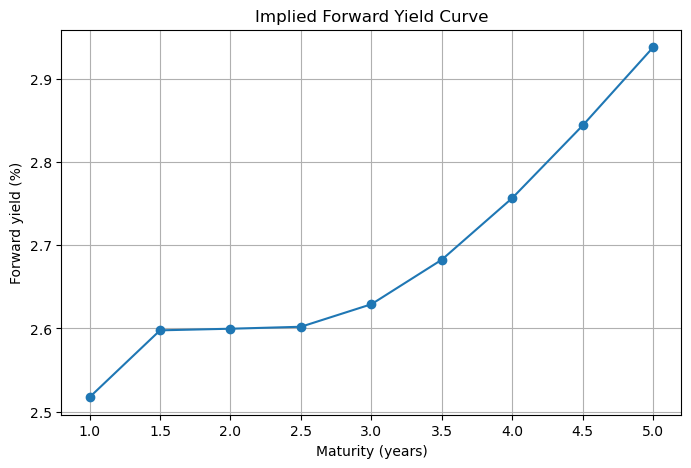

In [45]:
import matplotlib.pyplot as plt

plot_df = forward_df.dropna()

plt.figure(figsize=(8,5))
plt.plot(plot_df["maturity"], plot_df["forward_yield"], marker="o")
plt.xlabel("Maturity (years)")
plt.ylabel("Forward yield (%)")
plt.title("Implied Forward Yield Curve")
plt.grid(True)
plt.show()

### Interpretation

The implied forward yield curve is upward sloping over the selected maturities. The forward yields increase from about 2.52% at the 1 year maturity to about 2.94% at the 5-year maturity.

This means that the market-implied future short-term interest rates are higher for longer maturities than for shorter ones. In other words, investors currently require higher implied rates for lending over longer future periods.

From a macroeconomic perspective, this upward-sloping forward curve suggests expectations of stronger future economic activity, so the market expects future short term rates to rise gradually rather than fall.

Compared with the spot yield curve, the forward yield curve is steeper. This is because spot rates represent average annualized rates from today to each maturity, whereas forward rates represent the marginal implied rate between two consecutive maturities. As a result, forward rates react more strongly to changes in the slope of the term structure.

## 7. Valuation of a 3-Year French Government Bond

Assume that on 1 January 2025 the French government issues a 3-year government bond with par value equal to 1,000 euros and an annual coupon rate of 2%, paid semi-annually.

The bond therefore pays:
- a coupon of 10 euros every six months;
- and at maturity, the final coupon plus principal, equal to 1,010 euros.

The six cash flows are:

$$
CF_{0.5}=10,\quad
CF_{1.0}=10,\quad
CF_{1.5}=10,\quad
CF_{2.0}=10,\quad
CF_{2.5}=10,\quad
CF_{3.0}=1010
$$

### 7(a) Bond price using spot rates

Using spot rates, the bond price is equal to the present value of all future cash flows discounted at the corresponding spot yield for each maturity:

$$
P = \sum_{t=1}^{n} \frac{CF_t}{\left(1+\frac{s_t}{m}\right)^{m t}}
$$

where:
- \(CF_t\) is the cash flow at maturity \(t\),
- \(s_t\) is the spot yield for maturity \(t\),
- \(m=2\) because coupon payments are semi-annual.

For this bond, the price becomes:

$$
P =
\frac{10}{\left(1+\frac{s_{0.5}}{2}\right)^1}
+
\frac{10}{\left(1+\frac{s_{1.0}}{2}\right)^2}
+
\frac{10}{\left(1+\frac{s_{1.5}}{2}\right)^3}
+
\frac{10}{\left(1+\frac{s_{2.0}}{2}\right)^4}
+
\frac{10}{\left(1+\frac{s_{2.5}}{2}\right)^5}
+
\frac{1010}{\left(1+\frac{s_{3.0}}{2}\right)^6}
$$

In [46]:
bond_df = spot_df[spot_df["maturity"] <= 3.0].copy()

par = 1000
coupon_rate = 0.02
m = 2
coupon = par * coupon_rate / m

bond_df["cash_flow"] = coupon
bond_df.loc[bond_df["maturity"] == 3.0, "cash_flow"] = coupon + par

bond_df["spot_decimal"] = bond_df["spot_rate"] / 100
bond_df["discount_factor_spot"] = 1 / (1 + bond_df["spot_decimal"] / m) ** (m * bond_df["maturity"])
bond_df["pv_spot"] = bond_df["cash_flow"] * bond_df["discount_factor_spot"]

price_spot = bond_df["pv_spot"].sum()

bond_df[["maturity", "spot_rate", "cash_flow", "discount_factor_spot", "pv_spot"]], price_spot

(   maturity  spot_rate  cash_flow  discount_factor_spot     pv_spot
 0       0.5   2.158183       10.0              0.989324    9.893243
 1       1.0   2.337735       10.0              0.977026    9.770262
 2       1.5   2.424372       10.0              0.964499    9.644986
 3       2.0   2.468185       10.0              0.952122    9.521225
 4       2.5   2.494950       10.0              0.939894    9.398942
 5       3.0   2.517302     1010.0              0.927699  936.976183,
 np.float64(985.2048407464862))

The bond price obtained using spot rates is the sum of the present values of the six discounted cash flows.

### 7(b) Bond price using forward rates

Using forward rates, each cash flow is discounted by multiplying the one-period discount factors implied by the sequence of forward rates. The bond price can be written as:

$$
P =
\frac{10}{\left(1+\frac{f_{0,0.5}}{2}\right)}
+
\frac{10}{\left(1+\frac{f_{0,0.5}}{2}\right)\left(1+\frac{f_{0.5,1.0}}{2}\right)}
+
\frac{10}{\left(1+\frac{f_{0,0.5}}{2}\right)\left(1+\frac{f_{0.5,1.0}}{2}\right)\left(1+\frac{f_{1.0,1.5}}{2}\right)}
+ \cdots
+
\frac{1010}{\prod_{i=1}^{6}\left(1+\frac{f_i}{2}\right)}
$$

That is, each cash flow is discounted by the product of the semi-annual forward discount factors up to its maturity.

In [47]:
q7_df = spot_df[spot_df["maturity"] <= 3.0].copy()

par = 1000
coupon_rate = 0.02
m = 2
coupon = par * coupon_rate / m

q7_df["cash_flow"] = coupon
q7_df.loc[q7_df["maturity"] == 3.0, "cash_flow"] = coupon + par

q7_df["spot_decimal"] = q7_df["spot_rate"] / 100

forward_list = []

for i in range(len(q7_df)):
    if i == 0:
        f = q7_df.iloc[i]["spot_decimal"]
    else:
        t_prev = q7_df.iloc[i - 1]["maturity"]
        t = q7_df.iloc[i]["maturity"]
        s_prev = q7_df.iloc[i - 1]["spot_decimal"]
        s_t = q7_df.iloc[i]["spot_decimal"]

        f = m * (
            ((1 + s_t / m) ** (m * t)) /
            ((1 + s_prev / m) ** (m * t_prev))
            - 1
        )

    forward_list.append(f)

q7_df["forward_decimal"] = forward_list

discount_factors_forward = []
running_product = 1

for f in q7_df["forward_decimal"]:
    running_product *= (1 + f / m)
    discount_factors_forward.append(1 / running_product)

q7_df["discount_factor_forward"] = discount_factors_forward
q7_df["pv_forward"] = q7_df["cash_flow"] * q7_df["discount_factor_forward"]

price_forward = q7_df["pv_forward"].sum()

q7_df[["maturity", "cash_flow", "forward_decimal", "discount_factor_forward", "pv_forward"]], price_forward

(   maturity  cash_flow  forward_decimal  discount_factor_forward  pv_forward
 0       0.5       10.0         0.021582                 0.989324    9.893243
 1       1.0       10.0         0.025174                 0.977026    9.770262
 2       1.5       10.0         0.025978                 0.964499    9.644986
 3       2.0       10.0         0.025997                 0.952122    9.521225
 4       2.5       10.0         0.026020                 0.939894    9.398942
 5       3.0     1010.0         0.026291                 0.927699  936.976183,
 np.float64(985.2048407464862))

The bond price obtained using forward rates is the sum of the present values of the same cash flows discounted through the sequence of implied semi-annual forward rates.

### 7(c) Observation

The bond price obtained using spot rates and the bond price obtained using forward rates is the same:

$$
P_{\text{spot}} = P_{\text{forward}} = 985.2048407464862
$$

This result is expected because the forward rates are derived directly from the same spot rate curve through no-arbitrage relationships. Therefore, discounting the bond cash flows directly with spot rates or sequentially with forward rates must produce the same present value.

This shows that the spot curve and the forward curve are internally consistent. Any difference between the two methods would only come from rounding.

## 8. Dirty Price and Clean Price of the Bond 50 Days After Issuance

Assume that the 3-year French government bond is purchased 50 days after issuance. Since the bond was issued on 1 January 2025, the purchase date is 20 February 2025.

The bond pays a 2% annual coupon semi-annually on a par value of 1,000 euros, so each coupon payment is:

$$
C = \frac{0.02 \times 1000}{2} = 10
$$

The dirty price is the full market value of the bond, including accrued interest. The clean price is the quoted bond price excluding accrued interest.

Using spot rates, the dirty price at settlement is equal to the present value of the remaining cash flows, discounted from the settlement date rather than from the issue date.

Let

$$
\alpha = \frac{50}{181}
$$

represent the fraction of the current coupon period that has already elapsed.

The dirty price is therefore:

$$
P_{\text{dirty}} =
\frac{10}{\left(1+\frac{s_{0.5}}{2}\right)^{1-\alpha}}
+
\frac{10}{\left(1+\frac{s_{1.0}}{2}\right)^{2-\alpha}}
+
\frac{10}{\left(1+\frac{s_{1.5}}{2}\right)^{3-\alpha}}
+
\frac{10}{\left(1+\frac{s_{2.0}}{2}\right)^{4-\alpha}}
+
\frac{10}{\left(1+\frac{s_{2.5}}{2}\right)^{5-\alpha}}
+
\frac{1010}{\left(1+\frac{s_{3.0}}{2}\right)^{6-\alpha}}
$$

Accrued interest is calculated as:

$$
AI = C \times \frac{50}{181}
$$

The clean price is then:

$$
P_{\text{clean}} = P_{\text{dirty}} - AI
$$

For the accrued interest calculation, we assume a coupon period of 181 days between 1 January 2025 and 1 July 2025, so the accrued fraction is \(50/181\).

In [48]:
# Q8 - Compute the dirty price and the clean price 50 days after issuance

q8_df = spot_df[spot_df["maturity"] <= 3.0].copy()

par = 1000
coupon_rate = 0.02
m = 2
coupon = par * coupon_rate / m

q8_df["cash_flow"] = coupon
q8_df.loc[q8_df["maturity"] == 3.0, "cash_flow"] = coupon + par

days_accrued = 50
days_in_period = 181
alpha = days_accrued / days_in_period

q8_df["spot_decimal"] = q8_df["spot_rate"] / 100
q8_df["adjusted_exponent"] = m * q8_df["maturity"] - alpha
q8_df["discount_factor_dirty"] = 1 / (1 + q8_df["spot_decimal"] / m) ** q8_df["adjusted_exponent"]
q8_df["pv_dirty"] = q8_df["cash_flow"] * q8_df["discount_factor_dirty"]

dirty_price = q8_df["pv_dirty"].sum()
accrued_interest = coupon * alpha
clean_price = dirty_price - accrued_interest

q8_df[["maturity", "spot_rate", "cash_flow", "adjusted_exponent", "discount_factor_dirty", "pv_dirty"]], dirty_price, accrued_interest, clean_price

(   maturity  spot_rate  cash_flow  adjusted_exponent  discount_factor_dirty  \
 0       0.5   2.158183       10.0           0.723757               0.992262   
 1       1.0   2.337735       10.0           1.723757               0.980168   
 2       1.5   2.424372       10.0           2.723757               0.967714   
 3       2.0   2.468185       10.0           3.723757               0.955354   
 4       2.5   2.494950       10.0           4.723757               0.943119   
 5       3.0   2.517302     1010.0           5.723757               0.930910   
 
      pv_dirty  
 0    9.922619  
 1    9.801677  
 2    9.677142  
 3    9.553540  
 4    9.431187  
 5  940.219257  ,
 np.float64(988.6054216318512),
 2.7624309392265194,
 np.float64(985.8429906926247))

### Interpretation

The dirty price of the bond 50 days after issuance is:

$$
P_{\text{dirty}} = 988.6054216318512
$$

The accrued interest is:

$$
AI = 2.7624309392265194
$$

The clean price is therefore:

$$
P_{\text{clean}} = 985.8429906926247
$$

The dirty price is higher than the clean price because it includes accrued interest accumulated between the issue date and the settlement date.

The accrued interest is the portion of the next coupon that has already been earned by the seller during the 50 days since issuance. Therefore, the buyer pays the full dirty price, while the clean price is the quoted bond price excluding accrued interest.

The clean price remains below par value, which is consistent with the result obtained in Question 7, where the bond price was already below 1,000 euros because the market spot rates are above the bond coupon rate.

## 9. Yield to Maturity (YTM) of the Bond

The yield to maturity is the single discount rate that makes the present value of the bond's future cash flows equal to its observed price.

Using the bond price obtained in Question 7(a), the YTM is the value \(y\) that solves:

$$
985.2048407464862
=
\frac{10}{\left(1+\frac{y}{2}\right)^1}
+
\frac{10}{\left(1+\frac{y}{2}\right)^2}
+
\frac{10}{\left(1+\frac{y}{2}\right)^3}
+
\frac{10}{\left(1+\frac{y}{2}\right)^4}
+
\frac{10}{\left(1+\frac{y}{2}\right)^5}
+
\frac{1010}{\left(1+\frac{y}{2}\right)^6}
$$

The estimated yield to maturity is the constant annualized rate, with semi-annual compounding, that discounts all the bond cash flows to the price calculated previously.

In [49]:
# Q9 - Estimate the YTM of the bond priced in Q7

par = 1000
coupon_rate = 0.02
m = 2
coupon = par * coupon_rate / m
price_target = 985.2048407464862

cash_flows = [10, 10, 10, 10, 10, 1010]

def bond_price_ytm(y):
    price = 0
    for t, cf in enumerate(cash_flows, start=1):
        price += cf / (1 + y / m) ** t
    return price

best_y = None
min_error = float("inf")

y = 0.0001
while y <= 0.10:
    price = bond_price_ytm(y)
    error = abs(price - price_target)

    if error < min_error:
        min_error = error
        best_y = y

    y += 0.000001

ytm = best_y * 100
ytm

print("Estimated YTM (%):", round(ytm, 6))
print("Bond price from YTM:", round(bond_price_ytm(best_y), 6))
print("Target price:", round(price_target, 6))

Estimated YTM (%): 2.5151
Bond price from YTM: 985.204973
Target price: 985.204841


### Interpretation

The estimated yield to maturity of the bond is:

$$
YTM \approx 2.5151\%
$$

Using this yield, the bond price is:

$$
P \approx 985.204973
$$

which is extremely close to the target price from Question 7(a):

$$
P = 985.204841
$$

This confirms that the estimated YTM correctly reproduces the bond price.

The YTM is higher than the bond's coupon rate of 2%. This is consistent with the fact that the bond is priced below par value. When a bond trades below par, investors require a return greater than the coupon rate. Therefore, the YTM summarizes the bond's overall return if the bond is held to maturity and if all coupon payments are reinvested at the same rate.

## 10. DV01, Duration and Convexity

### 10(a) DV01 for a 5 basis points decrease in YTM

DV01 measures the change in bond value for a 1 basis point change in yield. Using the formula:

$$
DV01 = -\frac{\Delta BV}{10000 \cdot \Delta y}
$$

where:
- \(\Delta BV\) is the change in bond value,
- \(\Delta y\) is the change in yield in decimal form.

For a 5 basis points decrease in YTM:

$$
\Delta y = -0.0005
$$

we first reprice the bond using the new YTM and then compute the DV01.

In [50]:
# Q10.a - DV01 (5 bps decrease)
par = 1000
coupon_rate = 0.02
m = 2
coupon = par * coupon_rate / m
cash_flows = [10, 10, 10, 10, 10, 1010]

ytm = 0.025151
dy_5bps = -0.0005

def bond_price(y):
    price = 0
    for t, cf in enumerate(cash_flows, start=1):
        price += cf / (1 + y / m) ** t
    return price

price_0 = bond_price(ytm)
price_down_5bps = bond_price(ytm + dy_5bps)

delta_bv_5bps = price_down_5bps - price_0
dv01 = -(delta_bv_5bps) / (10000 * dy_5bps)

print("Initial price:", round(price_0, 6))
print("Price after 5 bps decrease:", round(price_down_5bps, 6))
print("Change in bond value:", round(delta_bv_5bps, 6))
print("DV01:", round(dv01, 6))

Initial price: 985.204973
Price after 5 bps decrease: 986.629673
Change in bond value: 1.4247
DV01: 0.28494


### 10(b) Duration and convexity for a 0.55% increase and decrease in YTM

To estimate duration and convexity, we shock the YTM upward and downward by 0.55%:

$$
\Delta y = 0.0055
$$

Using the bond prices after an upward and downward yield shock, duration is calculated as:

$$
D = - \frac{P_{+} - P_{-}}{2 P_0 \Delta y}
$$

Convexity is calculated as:

$$
C = \frac{P_{+} + P_{-} - 2P_0}{P_0 (\Delta y)^2}
$$

where:
- \(P_0\) is the initial bond price,
- \(P_{+}\) is the bond price after an increase in YTM,
- \(P_{-}\) is the bond price after a decrease in YTM.

In [51]:
# Q10.b - Duration and Convexity

dy_055 = 0.0055

price_up_055 = bond_price(ytm + dy_055)
price_down_055 = bond_price(ytm - dy_055)

duration = - (price_up_055 - price_down_055) / (2 * price_0 * dy_055)
convexity = (price_up_055 + price_down_055 - 2 * price_0) / (price_0 * dy_055 ** 2)

print("Initial price:", round(price_0, 6))
print("Price after +0.55% shock:", round(price_up_055, 6))
print("Price after -0.55% shock:", round(price_down_055, 6))
print("Duration:", round(duration, 6))
print("Convexity:", round(convexity, 6))

Initial price: 985.204973
Price after +0.55% shock: 969.693233
Price after -0.55% shock: 1001.011917
Duration: 2.889909
Convexity: 9.905377


### 10(c) Change in bond price for a 1.8% increase and decrease in YTM using the duration-convexity approach

Using duration and convexity, the approximate percentage change in bond price is:

$$
\frac{\Delta P}{P}
\approx
- D \Delta y + \frac{1}{2} C (\Delta y)^2
$$

We apply this formula for:
- an increase in YTM of 1.8%, so \(\Delta y = 0.018\),
- a decrease in YTM of 1.8%, so \(\Delta y = -0.018\).

The approximate change in bond price is then:

$$
\Delta P \approx P_0 \left(- D \Delta y + \frac{1}{2} C (\Delta y)^2 \right)
$$

In [52]:
# Q10.c - Price change (±1.8%)

dy_18_up = 0.018
dy_18_down = -0.018

pct_change_up = -duration * dy_18_up + 0.5 * convexity * (dy_18_up ** 2)
pct_change_down = -duration * dy_18_down + 0.5 * convexity * (dy_18_down ** 2)

delta_price_up = price_0 * pct_change_up
delta_price_down = price_0 * pct_change_down

approx_price_up = price_0 + delta_price_up
approx_price_down = price_0 + delta_price_down

print("Approximate % change for +1.8%:", round(pct_change_up, 6))
print("Approximate price change for +1.8%:", round(delta_price_up, 6))
print("Approximate bond price for +1.8%:", round(approx_price_up, 6))

print("Approximate % change for -1.8%:", round(pct_change_down, 6))
print("Approximate price change for -1.8%:", round(delta_price_down, 6))
print("Approximate bond price for -1.8%:", round(approx_price_down, 6))

Approximate % change for +1.8%: -0.050414
Approximate price change for +1.8%: -49.667826
Approximate bond price for +1.8%: 935.537147
Approximate % change for -1.8%: 0.053623
Approximate price change for -1.8%: 52.829686
Approximate bond price for -1.8%: 1038.034659


### Interpretation for Q10

### 10(a)

The initial bond price is:

$$
P_0 = 985.204973
$$

After a 5 basis points decrease in YTM, the bond price becomes:

$$
P_{-5\text{bps}} = 986.629673
$$

The change in bond value is therefore:

$$
\Delta BV = 986.629673 - 985.204973 = 1.424700
$$

Using the DV01 formula, we obtain:

$$
DV01 = 0.28494
$$

This means that, around the current yield level, the bond price changes by approximately 0.28494 euros for a 1 basis point change in YTM. Since the YTM decreases in this case, the bond price increases. This confirms the inverse relationship between bond prices and yields.

### 10(b)

Using a 0.55% upward and downward shock in YTM, the bond prices are:

$$
P_{+0.55\%} = 969.693233
$$

$$
P_{-0.55\%} = 1001.011917
$$

The estimated duration is:

$$
D = 2.889909
$$

The estimated convexity is:

$$
C = 9.905377
$$

The duration measures the first-order sensitivity of the bond price to changes in yield. A duration of 2.889909 means that the bond price is moderately sensitive to interest-rate movements.

The convexity is positive, which is the normal result for a standard government bond. Positive convexity means that the price-yield relationship is curved rather than linear. As a result, the bond price increases more when yields fall than it decreases when yields rise by the same amount.

Therefore, duration captures the linear effect of yield changes, while convexity improves the approximation by taking into account the curvature of the bond price-yield relationship.

### 10(c)

Using the duration-convexity approximation, a 1.8% increase in YTM produces an approximate percentage price change of:

$$
\frac{\Delta P}{P} \approx -0.050414
$$

This implies an approximate bond price change of:

$$
\Delta P \approx -49.667826
$$

and an approximate new bond price of:

$$
P \approx 935.537147
$$

For a 1.8% decrease in YTM, the approximate percentage price change is:

$$
\frac{\Delta P}{P} \approx 0.053623
$$

This implies an approximate bond price change of:

$$
\Delta P \approx 52.829686
$$

and an approximate new bond price of:

$$
P \approx 1038.034659
$$

These results confirm that when YTM increases, the bond price decreases, and when YTM decreases, the bond price increases.

They also show the effect of positive convexity: the gain in price for a 1.8% decrease in YTM is larger than the loss in price for a 1.8% increase in YTM. This asymmetry reflects the curve of the bond price-yield relationship and explains why the duration-convexity approach is more accurate than a duration-only approximation for larger yield changes.

## 11. Hedging Strategies Using Two Bonds

To construct hedging strategies, we consider two illustrative government bonds as hedging instruments:

- Hedge Bond 1: a 2-year government bond
- Hedge Bond 2: a 10-year government bond

We assume that we hold a long position of \$7.3 million in the bond calculated in Question 7(a). The objective is to hedge the interest-rate risk of this position using standard fixed-income risk measures.

For each hedging bond, we compute the price, DV01, duration and convexity. We then use these measures to construct three different hedging strategies.

In [53]:
# Original bond from Q7/Q10
price_op = 985.204973
dv01_op = 0.28494
duration_op = 2.889909
convexity_op = 9.905377

position_value = 7_300_000
n_op = position_value / price_op

total_dv01_op = dv01_op * n_op
dur_value_op = duration_op * position_value
conv_value_op = convexity_op * position_value

print("Number of original bonds:", n_op)
print("Total DV01 of original position:", total_dv01_op)
print("Duration-weighted value of original position:", dur_value_op)
print("Convexity-weighted value of original position:", conv_value_op)

Number of original bonds: 7409.625610974255
Total DV01 of original position: 2111.2987215910043
Duration-weighted value of original position: 21096335.7
Convexity-weighted value of original position: 72309252.1


In [54]:
def bond_price_from_ytm(par, coupon_rate, maturity_years, ytm, m=2):
    coupon = par * coupon_rate / m
    n_periods = int(maturity_years * m)
    price = 0
    for t in range(1, n_periods + 1):
        cf = coupon
        if t == n_periods:
            cf += par
        price += cf / (1 + ytm / m) ** t
    return price

def bond_dv01(par, coupon_rate, maturity_years, ytm, dy=-0.0005, m=2):
    p0 = bond_price_from_ytm(par, coupon_rate, maturity_years, ytm, m)
    p1 = bond_price_from_ytm(par, coupon_rate, maturity_years, ytm + dy, m)
    delta_bv = p1 - p0
    dv01 = -(delta_bv) / (10000 * dy)
    return p0, dv01

def bond_duration_convexity(par, coupon_rate, maturity_years, ytm, dy=0.0055, m=2):
    p0 = bond_price_from_ytm(par, coupon_rate, maturity_years, ytm, m)
    p_up = bond_price_from_ytm(par, coupon_rate, maturity_years, ytm + dy, m)
    p_down = bond_price_from_ytm(par, coupon_rate, maturity_years, ytm - dy, m)

    duration = - (p_up - p_down) / (2 * p0 * dy)
    convexity = (p_up + p_down - 2 * p0) / (p0 * dy ** 2)

    return p0, duration, convexity

# Same YTM assumption used for hedge bonds
ytm_hedge = 0.025151
par = 1000

# Hedge Bond 1: 2-year, 3% coupon
price_h1, dv01_h1 = bond_dv01(par, 0.03, 2, ytm_hedge)
_, duration_h1, convexity_h1 = bond_duration_convexity(par, 0.03, 2, ytm_hedge)

# Hedge Bond 2: 10-year, 4% coupon
price_h2, dv01_h2 = bond_dv01(par, 0.04, 10, ytm_hedge)
_, duration_h2, convexity_h2 = bond_duration_convexity(par, 0.04, 10, ytm_hedge)

print("Hedge Bond 1")
print("Price:", round(price_h1, 6))
print("DV01:", round(dv01_h1, 6))
print("Duration:", round(duration_h1, 6))
print("Convexity:", round(convexity_h1, 6))

print("\nHedge Bond 2")
print("Price:", round(price_h2, 6))
print("DV01:", round(dv01_h2, 6))
print("Duration:", round(duration_h2, 6))
print("Convexity:", round(convexity_h2, 6))

Hedge Bond 1
Price: 1009.40061
DV01: 0.19514
Duration: 1.93211
Convexity: 4.734893

Hedge Bond 2
Price: 1130.567889
DV01: 0.946634
Duration: 8.35699
Convexity: 81.567156


### 11(a) Hedging strategy with the first bond using the DV01 measure

Using the DV01 approach, the hedge ratio is:

$$
HR = \frac{DV01_{OP}}{DV01_{HI}}
$$

where:
- \(DV01_{OP}\) is the DV01 of the original position,
- \(DV01_{HI}\) is the DV01 of the hedging instrument.

The total DV01 of the original position is:

$$
DV01_{\text{position}} = DV01_{\text{bond}} \times N
$$

where \(N\) is the number of bonds held in the \$7.3M position.

The hedge position is then determined by:

$$
N_{H} = \frac{DV01_{\text{position}}}{DV01_{HI}}
$$

Because the original position is long, the hedge position must be short in the hedging bond in order to offset the price sensitivity to interest-rate changes.

This hedge neutralizes the first-order exposure of the portfolio to very small parallel changes in yields. However, it does not hedge differences in maturity structure or curvature risk.

In [55]:
n_h1_dv01 = total_dv01_op / dv01_h1
market_value_h1_dv01 = n_h1_dv01 * price_h1

print("11(a) DV01 hedge with bond 1")
print("Number of hedge bond 1 to short:", round(n_h1_dv01, 6))
print("Market value of hedge position:", round(market_value_h1_dv01, 6))

11(a) DV01 hedge with bond 1
Number of hedge bond 1 to short: 10819.418788
Market value of hedge position: 10921127.923428



### 11(b) Hedging strategy with the second bond using the duration measure

Using the duration approach, the hedge position is determined by equating the duration-weighted values of the original position and the hedging instrument:

$$
V_{HI} = - \frac{D_{OP} \times V_{OP}}{D_{HI}}
$$

where:
- \(D_{OP}\) is the duration of the original position,
- \(V_{OP}\) is the market value of the original position,
- \(D_{HI}\) is the duration of the hedging bond.

The negative sign means that the hedge position is short when the original position is long.

This hedge improves on the DV01 hedge because it scales the hedge using the value sensitivity of the positions. However, it still only matches first-order interest-rate risk and does not control for convexity differences.


In [56]:
market_value_h2_duration = - (duration_op * position_value) / duration_h2
n_h2_duration = market_value_h2_duration / price_h2

print("11(b) Duration hedge with bond 2")
print("Market value of hedge position:", round(market_value_h2_duration, 6))
print("Number of hedge bond 2 to short:", round(n_h2_duration, 6))

11(b) Duration hedge with bond 2
Market value of hedge position: -2524393.916566
Number of hedge bond 2 to short: -2232.854781



### 11(c) Hedging strategy with two bonds using the duration-convexity approach

To hedge both duration risk and convexity risk, we use the two hedging bonds simultaneously.

Let:
- \(x_1\) be the market value invested in Hedge Bond 1,
- \(x_2\) be the market value invested in Hedge Bond 2.

The hedge is obtained by solving the following system:

$$
D_{OP} \times V_{OP} + D_1 \times x_1 + D_2 \times x_2 = 0
$$

$$
C_{OP} \times V_{OP} + C_1 \times x_1 + C_2 \times x_2 = 0
$$

where:
- \(D_{OP}, C_{OP}\) are the duration and convexity of the original position,
- \(D_1, C_1\) are the duration and convexity of Hedge Bond 1,
- \(D_2, C_2\) are the duration and convexity of Hedge Bond 2.

The solution gives the two hedge positions that jointly offset both first-order and second-order sensitivity to interest-rate changes.

Compared with the previous hedges, this strategy is more robust because it neutralizes both the slope effect captured by duration and the curvature effect captured by convexity. It is therefore more appropriate when yield changes are large or when the hedging instruments have maturities that differ substantially from the original bond.

In [57]:
A = duration_h1
B = duration_h2
C = convexity_h1
D = convexity_h2

rhs1 = - duration_op * position_value
rhs2 = - convexity_op * position_value

det = A * D - B * C

x1 = (rhs1 * D - B * rhs2) / det
x2 = (A * rhs2 - rhs1 * C) / det

n_h1_dc = x1 / price_h1
n_h2_dc = x2 / price_h2

print("11(c) Duration-convexity hedge")
print("Market value in hedge bond 1:", round(x1, 6))
print("Market value in hedge bond 2:", round(x2, 6))
print("Number of hedge bond 1:", round(n_h1_dc, 6))
print("Number of hedge bond 2:", round(n_h2_dc, 6))

11(c) Duration-convexity hedge
Market value in hedge bond 1: -9459511.329834
Market value in hedge bond 2: -337384.254566
Number of hedge bond 1: -9371.414319
Number of hedge bond 2: -298.420164


## Interpretation

To hedge the interest-rate risk of the original long position of 7.3 million in the bond calculated in Question 7(a), we use two hypothetical government bonds as hedging instruments:

- hedge bond 1: a 2-year bond with a 3% annual coupon
- hedge bond 2: a 10-year bond with a 4% annual coupon

From the previous calculations, the original position has the following exposures:

$$
\text{Number of original bonds} = 7409.625611
$$

$$
\text{Total DV01 of original position} = 2111.298722
$$

$$
\text{Duration-weighted value of original position} = 21096335.7
$$

$$
\text{Convexity-weighted value of original position} = 72309252.1
$$

### 11(a) Hedging strategy with the first bond using the DV01 measure

Using the DV01 hedge with hedge bond 1, the required hedge position is:

$$
\text{Number of hedge bond 1 to short} = 10819.418788
$$

$$
\text{Market value of hedge position} = 10921127.923428
$$

This hedge helps to reduce the risk of the investment when there are small changes in interest rates. Since the original investment is a position the hedge needs to be a short position in a specific bond called hedge bond 1.

The DV01 hedge is a way to reduce risk when interest rates change a little but it only works well for small changes. It does not take into account the differences in how the investments will last or how much their value will change when interest rates change. So when interest rates change a lot the DV01 hedge may not be very accurate.

### 11(b) Hedging strategy with the second bond using the duration measure

Using the duration hedge with hedge bond 2, the required hedge position is:

$$
\text{Market value of hedge position} = -2524393.916566
$$

$$
\text{Number of hedge bond 2 to short} = -2232.854781
$$

The negative sign shows that the hedge position is short which makes sense because the original investment is long.

This hedge is better than the DV01 hedge because it uses the duration sensitivity of the investments to determine the size of the hedge. However it still only reduces the risk of changes in interest rates and does not account for the way the price of the investment changes when interest rates change.

### 11(c) Hedging strategy with the two bonds using the duration-convexity approach

Using both hedge bond 1 and hedge bond 2, the duration-convexity hedge gives the following solution:

$$
\text{Market value in hedge bond 1} = -9459511.329834
$$

$$
\text{Market value in hedge bond 2} = -337384.254566
$$

$$
\text{Number of hedge bond 1} = -9371.414319
$$

$$
\text{Number of hedge bond 2} = -298.420164
$$

Both hedge positions are negative which means that both investments need to be shorted to reduce the risk of the original investment.

This is the hedging strategy because it reduces both the risk of small changes in interest rates and the risk of larger changes. Thus, it helps to offset both the initial effect of interest rate changes and the secondary effect of how much the price of the investment will change.

Compared to the strategies the duration-convexity hedge is more reliable especially when interest rates change a lot or when the investments used for hedging have very different lifespans than the original bond. Therefore it provides the protection against changes in interest rates over time.